In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("airline unclean.csv")

In [3]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      103904 non-null

In [5]:
df.columns = df.columns.str.strip().str.lower()

In [6]:
df.isnull().sum()

unnamed: 0                             0
id                                     0
gender                                 0
customer type                          0
age                                    0
type of travel                         0
class                                  0
flight distance                        0
inflight wifi service                  0
departure/arrival time convenient      0
ease of online booking                 0
gate location                          0
food and drink                         0
online boarding                        0
seat comfort                           0
inflight entertainment                 0
on-board service                       0
leg room service                       0
baggage handling                       0
checkin service                        0
inflight service                       0
cleanliness                            0
departure delay in minutes             0
arrival delay in minutes             310
satisfaction    

In [7]:
df['arrival delay in minutes'] = df['arrival delay in minutes'].fillna(df['arrival delay in minutes'].median())

In [8]:
df.head(1)

,unnamed: 0,id,gender,customer type,age,type of travel,class,flight distance,inflight wifi service,departure/arrival time convenient,...,inflight entertainment,on-board service,leg room service,baggage handling,checkin service,inflight service,cleanliness,departure delay in minutes,arrival delay in minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied


In [9]:
df = df.drop(columns = 'unnamed: 0')

In [10]:
#Step 7 — for remove all whitespaces and lower the text in all columns on one code
text_col = df.select_dtypes(include = 'object').columns
for col in text_col:
    df[col] = df[col].str.strip().str.lower()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28240\3809689983.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include = 'object').columns


In [11]:
#Step 8 — Negative values check
df.select_dtypes(include='number').min().values

array([ 1.,  7., 31.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        1.,  0.,  0.,  0.,  0.,  0.])

In [12]:
#Q8. Missing values percentage?
(df.isnull().sum() / len(df) * 100).sort_values(ascending = False)

id                                   0.0
gender                               0.0
customer type                        0.0
age                                  0.0
type of travel                       0.0
class                                0.0
flight distance                      0.0
inflight wifi service                0.0
departure/arrival time convenient    0.0
ease of online booking               0.0
gate location                        0.0
food and drink                       0.0
online boarding                      0.0
seat comfort                         0.0
inflight entertainment               0.0
on-board service                     0.0
leg room service                     0.0
baggage handling                     0.0
checkin service                      0.0
inflight service                     0.0
cleanliness                          0.0
departure delay in minutes           0.0
arrival delay in minutes             0.0
satisfaction                         0.0
dtype: float64

In [13]:
#Q20. Passengers older than 50?
df[df['age'] > 50].shape[0]

26745

In [14]:
#Q22. Age-wise average satisfaction?
df.groupby('age')['satisfaction'].apply(lambda x : (x == 'satisfied').mean() * 100)

age
7      9.964413
8     10.781250
9     13.728324
10    13.177160
11    16.076696
        ...    
77    18.390805
78    33.333333
79    28.571429
80    19.230769
85    17.647059
Name: satisfaction, Length: 75, dtype: float64

In [15]:
#Q26. Average distance by class?
df.groupby('class')['flight distance'].mean()

class
business    1675.976925
eco          743.439748
eco plus     747.125567
Name: flight distance, dtype: float64

In [16]:
#Q27. Average distance by travel type?
df.groupby('type of travel')['flight distance'].mean()

type of travel
business travel    1368.287237
personal travel     792.081057
Name: flight distance, dtype: float64

In [17]:
#Q28. Total flight distance?
df['flight distance'].sum()

np.int64(123588444)

In [18]:
#Q29. Average departure delay?
df['departure delay in minutes'].mean()

np.float64(14.815618263012011)

In [19]:
#q30. Average arrival delay?
df['arrival delay in minutes'].mean()

np.float64(15.133392362180475)

In [20]:
#Q31. Maximum departure delay?
df['departure delay in minutes'].max()

np.int64(1592)

In [21]:
#Q32. Maximum arrival delay?
df['arrival delay in minutes'].max()

np.float64(1584.0)

In [22]:
#Q33. Passengers with departure delay > 30 minutes?
df[df['departure delay in minutes'] > 30 ].shape[0]

14529

In [23]:
#Q34. Passengers with arrival delay > 30 minutes?
df[df['arrival delay in minutes'] > 30].shape[0]

14662

In [24]:
#Q35. Percentage of passengers experiencing departure delay?
(df['departure delay in minutes'] > 0 ).mean() * 100

np.float64(43.53634123806591)

In [25]:
#Q36. Percentage experiencing arrival delay?
(df['arrival delay in minutes'] > 0).mean() * 100

np.float64(43.72786418232214)

In [26]:
df.head(1)

,id,gender,customer type,age,type of travel,class,flight distance,inflight wifi service,departure/arrival time convenient,ease of online booking,...,inflight entertainment,on-board service,leg room service,baggage handling,checkin service,inflight service,cleanliness,departure delay in minutes,arrival delay in minutes,satisfaction
0,70172,male,loyal customer,13,personal travel,eco plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied


In [27]:
#Q37. Average inflight wifi rating?
df['inflight wifi service'].mean()

np.float64(2.72968316907915)

In [28]:
#Q43. Overall satisfaction percentage?
df['satisfaction'].value_counts(normalize = True) * 100

satisfaction
neutral or dissatisfied    56.666731
satisfied                  43.333269
Name: proportion, dtype: float64

In [29]:
df['satisfaction'].value_counts(normalize =True) * 100

satisfaction
neutral or dissatisfied    56.666731
satisfied                  43.333269
Name: proportion, dtype: float64

In [30]:
#Q44. Satisfaction by gender?
pd.crosstab(
    df['gender'],
    df['satisfaction'],
    normalize = 'index'
)* 100

satisfaction,neutral or dissatisfied,satisfied
gender,,
female,57.262882,42.737118
male,56.052524,43.947476


In [31]:
# Q45. Satisfaction by class?
pd.crosstab(
    df['class'],
    df['satisfaction'],
    normalize ='index'
) *100

satisfaction,neutral or dissatisfied,satisfied
class,,
business,30.574852,69.425148
eco,81.386245,18.613755
eco plus,75.393648,24.606352


In [32]:
#Q46. Satisfaction by travel type?
pd.crosstab(
    df['type of travel'],
    df['satisfaction'],
    normalize = 'index'
) * 100

satisfaction,neutral or dissatisfied,satisfied
type of travel,,
business travel,41.740283,58.259717
personal travel,89.832243,10.167757


In [33]:
#Q47. Satisfaction by customer type?
pd.crosstab(
    df['customer type'],
    df['satisfaction'],
    normalize = 'index'
) *100

satisfaction,neutral or dissatisfied,satisfied
customer type,,
disloyal customer,76.334229,23.665771
loyal customer,52.270881,47.729119


In [34]:
#Q48. Average delay for satisfied vs dissatisfied?
df.groupby('satisfaction')[['departure delay in minutes','arrival delay in minutes']].mean()

,departure delay in minutes,arrival delay in minutes
satisfaction,,
neutral or dissatisfied,16.503728,17.074594
satisfied,12.608084,12.594892


In [35]:
#Q49. Average service ratings by satisfaction?
service_cols = [
    'inflight wifi service',
    'food and drink',
    'online boarding',
    'seat comfort',
    'inflight entertainment',
    'on-board service',
    'leg room service',
    'baggage handling',
    'checkin service',
    'inflight service',
    'cleanliness'
]
df.groupby('satisfaction')[service_cols].mean()

,inflight wifi service,food and drink,online boarding,seat comfort,inflight entertainment,on-board service,leg room service,baggage handling,checkin service,inflight service,cleanliness
satisfaction,,,,,,,,,,,
neutral or dissatisfied,2.399633,2.95805,2.656125,3.036295,2.894156,3.019158,2.990812,3.375991,3.042952,3.388814,2.936123
satisfied,3.161288,3.52131,4.027474,3.966530,3.964931,3.857324,3.822143,3.966396,3.646041,3.969461,3.744342


In [36]:
#Q50. Kaunsi service satisfaction ko sabse zyada differentiate karti hai?
df.groupby('satisfaction')[service_cols].mean().T.sort_values(by = 'satisfied', ascending= False)

satisfaction,neutral or dissatisfied,satisfied
online boarding,2.656125,4.027474
inflight service,3.388814,3.969461
seat comfort,3.036295,3.966530
baggage handling,3.375991,3.966396
inflight entertainment,2.894156,3.964931
on-board service,3.019158,3.857324
leg room service,2.990812,3.822143
cleanliness,2.936123,3.744342
checkin service,3.042952,3.646041
food and drink,2.958050,3.521310


In [37]:
#Q51. Age groups banao.
bins = [1,18,30,45,60,100]
labels = ['under 18','18-30','31-45','46-60','60+']
df['age_group'] = pd.cut(df['age'],bins = bins,labels = labels)

In [38]:
df.head(1)

,id,gender,customer type,age,type of travel,class,flight distance,inflight wifi service,departure/arrival time convenient,ease of online booking,...,on-board service,leg room service,baggage handling,checkin service,inflight service,cleanliness,departure delay in minutes,arrival delay in minutes,satisfaction,age_group
0,70172,male,loyal customer,13,personal travel,eco plus,460,3,4,3,...,4,3,4,4,5,5,25,18.0,neutral or dissatisfied,under 18


In [39]:
#Q52. Age group-wise satisfaction?
pd.crosstab(
    df['age_group'],
    df['satisfaction'],
    normalize = 'index'
) * 100

satisfaction,neutral or dissatisfied,satisfied
age_group,,
under 18,82.725334,17.274666
18-30,64.588225,35.411775
31-45,51.272104,48.727896
46-60,42.591664,57.408336
60+,79.162487,20.837513


In [40]:
#Q53. Delay category banao.
df['delay_group'] = pd.cut(
    df['departure delay in minutes'],
    bins = [0,15,30,45,60,float('inf')],
    labels = ['no delay','15-30','31-45','46-60','60+'])

In [41]:
df.head(1)

,id,gender,customer type,age,type of travel,class,flight distance,inflight wifi service,departure/arrival time convenient,ease of online booking,...,leg room service,baggage handling,checkin service,inflight service,cleanliness,departure delay in minutes,arrival delay in minutes,satisfaction,age_group,delay_group
0,70172,male,loyal customer,13,personal travel,eco plus,460,3,4,3,...,3,4,4,5,5,25,18.0,neutral or dissatisfied,under 18,15-30


In [42]:
#Q54. Delay category-wise satisfaction?
pd.crosstab(
    df['delay_group'],
    df['satisfaction'],
    normalize = 'index'
) * 100

satisfaction,neutral or dissatisfied,satisfied
delay_group,,
no delay,56.342409,43.657591
15-30,61.750557,38.249443
31-45,63.369803,36.630197
46-60,64.080882,35.919118
60+,64.263020,35.736980


In [43]:
#Q55. Overall service score banao.
df['service_score'] = df[service_cols].mean(axis = 1)

In [44]:
df.head(1)

,id,gender,customer type,age,type of travel,class,flight distance,inflight wifi service,departure/arrival time convenient,ease of online booking,...,baggage handling,checkin service,inflight service,cleanliness,departure delay in minutes,arrival delay in minutes,satisfaction,age_group,delay_group,service_score
0,70172,male,loyal customer,13,personal travel,eco plus,460,3,4,3,...,4,4,5,5,25,18.0,neutral or dissatisfied,under 18,15-30,4.181818


In [45]:
#Q56. Service Score by satisfaction?
df.groupby('satisfaction')['service_score'].mean().reset_index()

,satisfaction,service_score
0,neutral or dissatisfied,2.972555
1,satisfied,3.786113


In [46]:
#Q57. Class + Travel Type satisfaction?
pd.crosstab(
    [df['class'],
    df['type of travel']],
    df['satisfaction'],
    normalize = 'index'
) * 100

satisfaction              neutral or dissatisfied  satisfied
class    type of travel                                     
business business travel                27.978446  72.021554
         personal travel                87.760779  12.239221
eco      business travel                70.380609  29.619391
         personal travel                89.802930  10.197070
eco plus business travel                60.668380  39.331620
         personal travel                91.287458   8.712542

In [47]:
#Q58. Top 10 longest flights?
df.nlargest(10, ['flight distance'])[['id','age','class','type of travel','flight distance']]

,id,age,class,type of travel,flight distance
2847,31870,63,business,personal travel,4983
18434,31876,31,eco,business travel,4983
19755,31871,50,business,business travel,4983
33094,31878,29,eco,personal travel,4983
46848,31812,42,business,business travel,4983
64631,31875,52,business,business travel,4983
64791,31873,50,business,business travel,4983
67767,31880,67,eco plus,personal travel,4983
74837,31813,37,business,business travel,4983
79574,31817,38,eco plus,business travel,4983


In [48]:
#Q59. Top 10 highest departure delays?
df.nlargest(10,['departure delay in minutes'])[['id','class','type of travel','departure delay in minutes']]

,id,class,type of travel,departure delay in minutes
83741,73471,eco,personal travel,1592
6744,69661,business,business travel,1305
61310,4903,business,business travel,1017
72206,78300,eco,personal travel,978
80182,8345,business,business travel,933
61287,4376,business,business travel,930
61528,83676,business,business travel,921
27732,69504,business,business travel,859
51860,79912,business,business travel,853
37096,78292,eco,business travel,750


In [49]:
df.head(1)

,id,gender,customer type,age,type of travel,class,flight distance,inflight wifi service,departure/arrival time convenient,ease of online booking,...,baggage handling,checkin service,inflight service,cleanliness,departure delay in minutes,arrival delay in minutes,satisfaction,age_group,delay_group,service_score
0,70172,male,loyal customer,13,personal travel,eco plus,460,3,4,3,...,4,4,5,5,25,18.0,neutral or dissatisfied,under 18,15-30,4.181818


In [50]:
df.columns.values

<StringArray>
[                               'id',                            'gender',
                     'customer type',                               'age',
                    'type of travel',                             'class',
                   'flight distance',             'inflight wifi service',
 'departure/arrival time convenient',            'ease of online booking',
                     'gate location',                    'food and drink',
                   'online boarding',                      'seat comfort',
            'inflight entertainment',                  'on-board service',
                  'leg room service',                  'baggage handling',
                   'checkin service',                  'inflight service',
                       'cleanliness',        'departure delay in minutes',
          'arrival delay in minutes',                      'satisfaction',
                         'age_group',                       'delay_group',
           

In [51]:
df = df.rename(columns ={'customer type':'customer_type','type of travel':'travelling_type','flight distance':'flight_distance',
                         'inflight wifi service':'wifi_service','departure/arrival time convenient':'departure_arrival_time',
                         'gate location':'gate_location','online boarding':'online_boarding','inflight entertainment':'inflight_entertainment',
                         'leg room service':'leg_room_service','checkin service':'checkin_service','arrival delay in minutes':'arrival_delay',
                         'ease of online booking':'ease_online_booking','food and drink':'food_drinks','seat comfort':'seat_comfort',
                         'on-board service':'on_board_service','baggage handling':'baggage_handling','inflight service':'inflight_service',
                         'departure delay in minutes':'departure_delay'})

In [52]:
df.head(1)

,id,gender,customer_type,age,travelling_type,class,flight_distance,wifi_service,departure_arrival_time,ease_online_booking,...,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay,arrival_delay,satisfaction,age_group,delay_group,service_score
0,70172,male,loyal customer,13,personal travel,eco plus,460,3,4,3,...,4,4,5,5,25,18.0,neutral or dissatisfied,under 18,15-30,4.181818


In [53]:
#Q59. Top 10 highest departure delays?
df.nlargest(10,['departure_delay'])[['id','gender','customer_type','travelling_type','departure_delay']]

,id,gender,customer_type,travelling_type,departure_delay
83741,73471,female,loyal customer,personal travel,1592
6744,69661,male,loyal customer,business travel,1305
61310,4903,male,loyal customer,business travel,1017
72206,78300,male,loyal customer,personal travel,978
80182,8345,male,loyal customer,business travel,933
61287,4376,female,loyal customer,business travel,930
61528,83676,male,disloyal customer,business travel,921
27732,69504,male,loyal customer,business travel,859
51860,79912,male,loyal customer,business travel,853
37096,78292,male,loyal customer,business travel,750


In [54]:
#Q60. Correlation matrix?
df.select_dtypes(include = 'number').corr()

,id,age,flight_distance,wifi_service,departure_arrival_time,ease_online_booking,gate_location,food_drinks,online_boarding,seat_comfort,inflight_entertainment,on_board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay,arrival_delay,service_score
id,1.000000,0.022857,0.095544,-0.021276,-0.002110,0.014163,-0.000606,0.001063,0.055477,0.052903,0.002300,0.055241,0.044634,0.074940,0.079273,0.079346,0.024965,-0.019546,-0.036997,0.069994
age,0.022857,1.000000,0.099461,0.017859,0.038125,0.024842,-0.001330,0.023000,0.208939,0.160277,0.076444,0.057594,0.040583,-0.047529,0.035482,-0.049427,0.053611,-0.010152,-0.012105,0.096297
flight_distance,0.095544,0.099461,1.000000,0.007131,-0.020043,0.065717,0.004793,0.056994,0.214869,0.157333,0.128740,0.109526,0.133916,0.063184,0.073072,0.057540,0.093149,0.002158,-0.002470,0.176784
wifi_service,-0.021276,0.017859,0.007131,1.000000,0.343845,0.715856,0.336248,0.134718,0.456970,0.122658,0.209321,0.121500,0.160473,0.120923,0.043193,0.110441,0.132698,-0.017402,-0.019042,0.424885
departure_arrival_time,-0.002110,0.038125,-0.020043,0.343845,1.000000,0.436961,0.444757,0.004906,0.070119,0.011344,-0.004861,0.068882,0.012441,0.072126,0.093333,0.073318,0.014292,0.001005,-0.000918,0.121214
ease_online_booking,0.014163,0.024842,0.065717,0.715856,0.436961,1.000000,0.458655,0.031873,0.404074,0.030014,0.047032,0.038833,0.107601,0.038762,0.011081,0.035272,0.016179,-0.006371,-0.007947,0.241871
gate_location,-0.000606,-0.001330,0.004793,0.336248,0.444757,0.458655,1.000000,-0.001159,0.001688,0.003669,0.003517,-0.028373,-0.005873,0.002313,-0.035427,0.001681,-0.003830,0.005467,0.005178,0.045454
food_drinks,0.001063,0.023000,0.056994,0.134718,0.004906,0.031873,-0.001159,1.000000,0.234468,0.574556,0.622512,0.059073,0.032498,0.034746,0.087299,0.033993,0.657760,-0.029926,-0.032466,0.567499
online_boarding,0.055477,0.208939,0.214869,0.456970,0.070119,0.404074,0.001688,0.234468,1.000000,0.420211,0.285066,0.155443,0.123950,0.083280,0.204462,0.074573,0.331517,-0.018982,-0.021874,0.550102
seat_comfort,0.052903,0.160277,0.157333,0.122658,0.011344,0.030014,0.003669,0.574556,0.420211,1.000000,0.610590,0.131971,0.105559,0.074542,0.191854,0.069218,0.678534,-0.027898,-0.029735,0.648221


In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

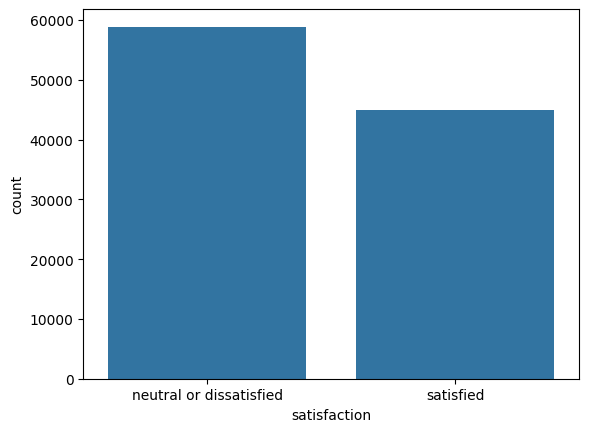

In [56]:
#Chart 1 — Satisfaction distribution
sns.countplot(data = df, x='satisfaction')
plt.show()

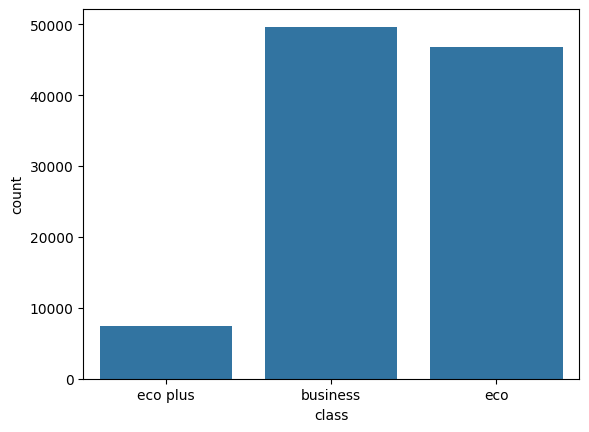

In [57]:
#Chart 2 — Class distribution
sns.countplot(data=df,x='class')
plt.show()

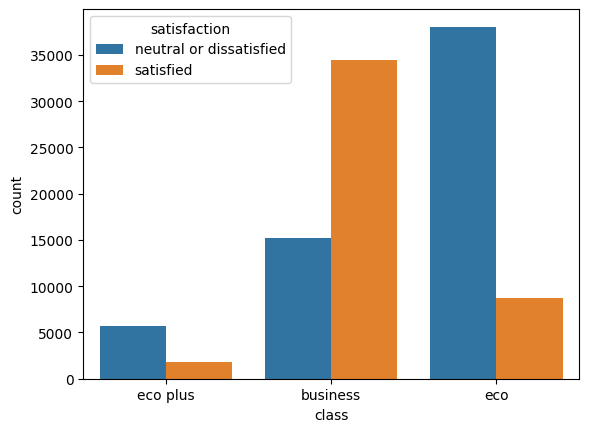

In [58]:
#Chart 3 — Satisfaction by Class
sns.countplot(data = df,x ='class',hue = 'satisfaction')
plt.show()

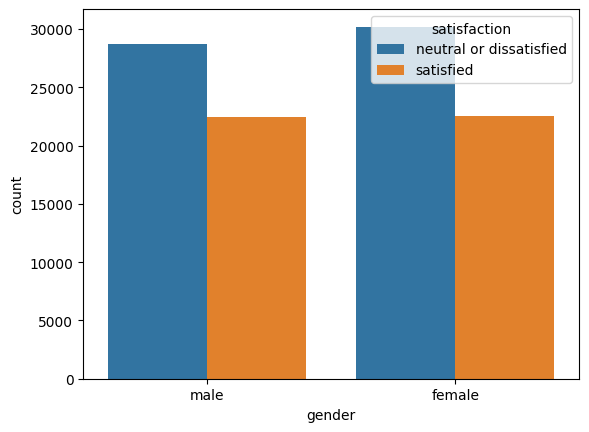

In [59]:
#Chart 4 — Satisfaction by Gender
sns.countplot(data = df,x='gender',hue='satisfaction')
plt.show()

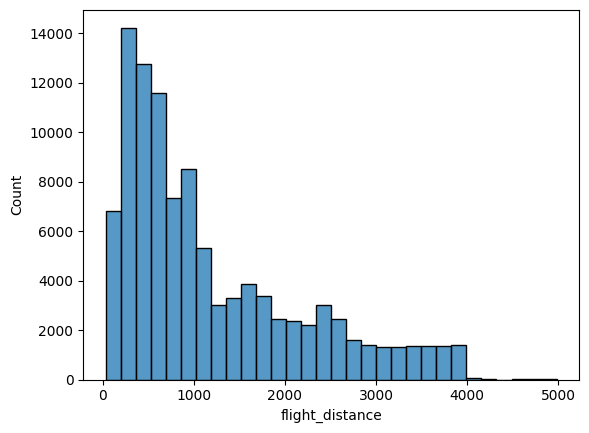

In [60]:
#Chart 5 — Flight Distance Distribution
sns.histplot(df['flight_distance'],bins=30)
plt.show()

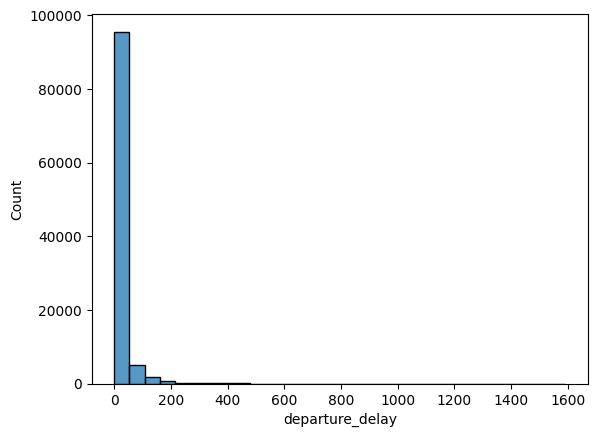

In [61]:
#Chart 6 — Departure Delay Distribution
sns.histplot(df['departure_delay'],bins=30)
plt.show()

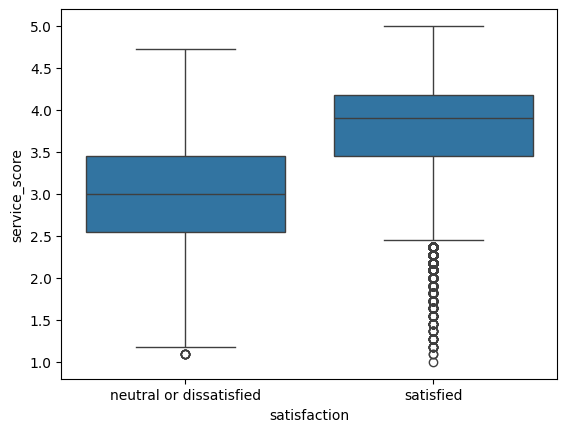

In [62]:
#Chart 7 — Service Score vs Satisfaction
sns.boxplot(data=df,x='satisfaction',y='service_score')
plt.show()

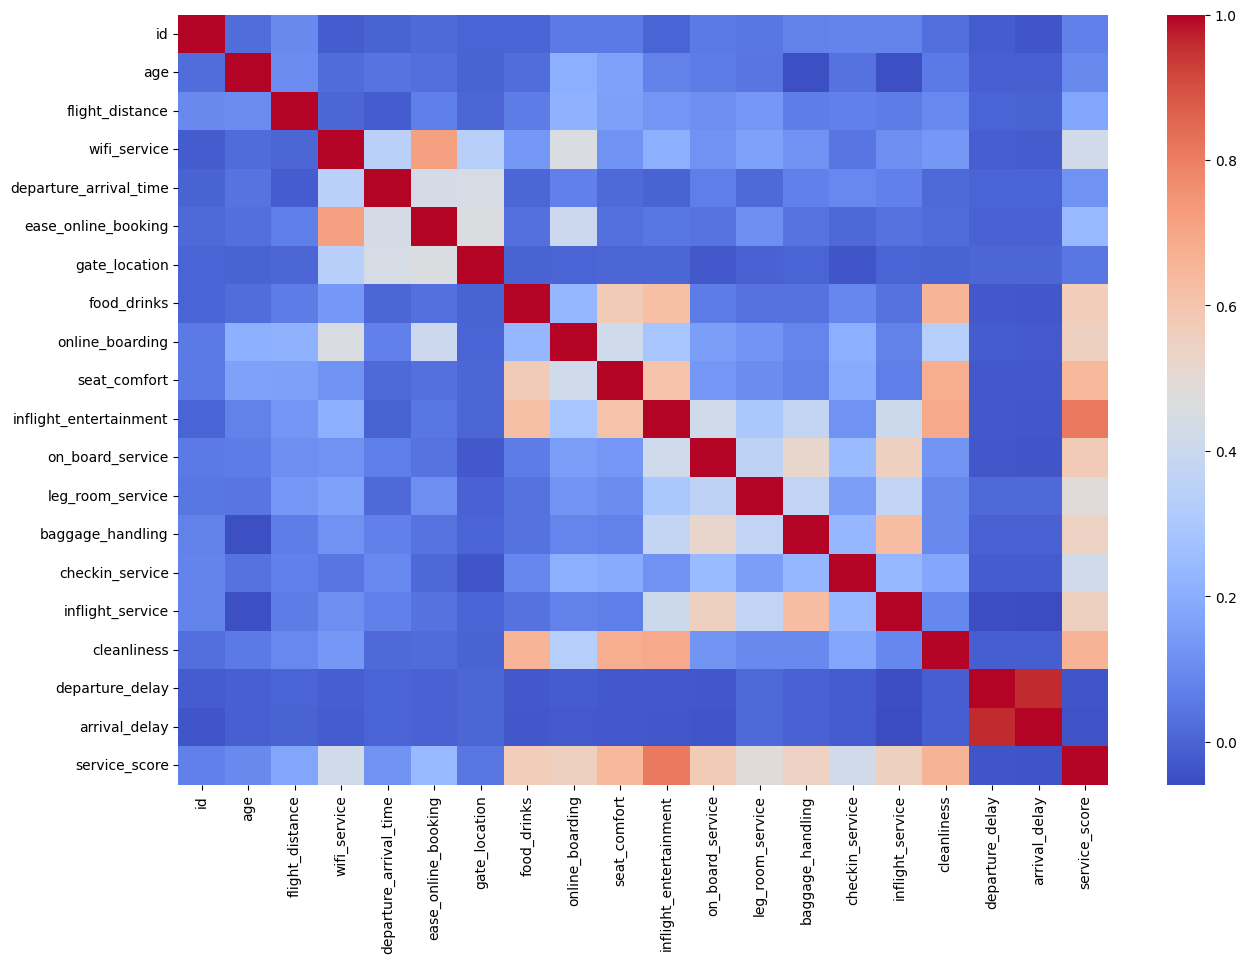

In [63]:
#Chart 8 — Correlation Heatmap
plt.figure(figsize=(15,10))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    cmap='coolwarm')
plt.show()

In [64]:
df.groupby('gender')['wifi_service'].mean().sort_values().reset_index()

,gender,wifi_service
0,female,2.717943
1,male,2.741779


In [65]:
#Group by Type of Travel and Class together, and find average satisfaction ratings
df.groupby(['travelling_type','class'])[['wifi_service','seat_comfort','service_score']].mean()

wifi_service  seat_comfort  service_score
travelling_type class                                              
business travel business      2.785594      3.774438       3.584489
                eco           2.875154      3.097645       3.047826
                eco plus      3.013625      3.155013       3.050970
personal travel business      2.548911      3.461752       3.145278
                eco           2.522048      3.170341       3.149859
                eco plus      2.502775      3.214761       3.155660

In [66]:
df.groupby('class')['flight_distance'].agg(['min','mean','max'])

,min,mean,max
class,,,
business,56,1675.976925,4983
eco,31,743.439748,4983
eco plus,31,747.125567,4983


In [67]:
df['sat_num']= (df['satisfaction'] == 'satisfied')
pd.pivot_table(df,values ='sat_num',index ='class',columns= 'gender',aggfunc='mean')

gender,female,male
class,,
business,0.690697,0.697833
eco,0.183880,0.188491
eco plus,0.235921,0.257320


In [68]:
df[(df['inflight_entertainment'] ==5) & (df['satisfaction'] != 'satisfied')]

,id,gender,customer_type,age,travelling_type,class,flight_distance,wifi_service,departure_arrival_time,ease_online_booking,...,checkin_service,inflight_service,cleanliness,departure_delay,arrival_delay,satisfaction,age_group,delay_group,service_score,sat_num
0,70172,male,loyal customer,13,personal travel,eco plus,460,3,4,3,...,4,5,5,25,18.0,neutral or dissatisfied,under 18,15-30,4.181818,False
19,66246,male,loyal customer,38,personal travel,eco,460,2,3,3,...,3,2,5,17,18.0,neutral or dissatisfied,31-45,15-30,3.363636,False
21,22434,female,loyal customer,17,personal travel,eco,208,3,1,3,...,3,4,5,0,0.0,neutral or dissatisfied,under 18,NaN,3.909091,False
25,102956,male,loyal customer,57,personal travel,eco,719,4,4,4,...,4,5,5,27,28.0,neutral or dissatisfied,46-60,15-30,4.181818,False
31,27809,female,disloyal customer,15,business travel,eco,1043,2,2,2,...,2,4,5,3,0.0,neutral or dissatisfied,under 18,no delay,3.454545,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103851,112270,male,disloyal customer,8,business travel,eco,1036,3,3,3,...,5,4,5,1,0.0,neutral or dissatisfied,under 18,no delay,4.181818,False
103857,51504,male,disloyal customer,26,business travel,eco,370,2,3,2,...,3,3,5,0,0.0,neutral or dissatisfied,18-30,NaN,3.727273,False
103868,37051,female,loyal customer,57,personal travel,eco plus,1105,1,5,1,...,1,5,1,0,1.0,neutral or dissatisfied,46-60,NaN,3.090909,False
103884,6737,female,loyal customer,19,personal travel,eco,334,2,5,2,...,3,5,5,25,11.0,neutral or dissatisfied,18-30,15-30,3.727273,False


In [69]:
df[df['customer_type'].str.contains('disloyal',case=False)]

,id,gender,customer_type,age,travelling_type,class,flight_distance,wifi_service,departure_arrival_time,ease_online_booking,...,checkin_service,inflight_service,cleanliness,departure_delay,arrival_delay,satisfaction,age_group,delay_group,service_score,sat_num
1,5047,male,disloyal customer,25,business travel,business,235,3,2,3,...,1,4,1,1,6.0,neutral or dissatisfied,18-30,no delay,2.181818,False
9,65725,male,disloyal customer,20,business travel,eco,1061,3,3,3,...,4,3,2,0,0.0,neutral or dissatisfied,18-30,NaN,2.818182,False
10,34991,female,disloyal customer,24,business travel,eco,1182,4,5,5,...,3,5,2,0,0.0,neutral or dissatisfied,18-30,NaN,3.272727,False
15,100580,male,disloyal customer,13,business travel,eco,486,2,1,2,...,1,3,4,1,0.0,neutral or dissatisfied,under 18,no delay,2.545455,False
24,105420,female,disloyal customer,23,business travel,eco,452,5,0,5,...,3,5,1,54,44.0,satisfied,18-30,46-60,3.272727,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103892,46016,female,disloyal customer,37,business travel,business,596,3,3,3,...,1,4,3,110,121.0,neutral or dissatisfied,31-45,60+,2.545455,False
103895,66030,female,disloyal customer,24,business travel,eco,1055,1,1,1,...,5,4,1,13,10.0,neutral or dissatisfied,18-30,no delay,2.363636,False
103899,94171,female,disloyal customer,23,business travel,eco,192,2,1,2,...,2,3,2,3,0.0,neutral or dissatisfied,18-30,no delay,2.272727,False
103901,68825,male,disloyal customer,30,business travel,business,1995,1,1,1,...,5,5,4,7,14.0,neutral or dissatisfied,18-30,no delay,3.454545,False


In [70]:
df['age'].mode()[0]

np.int64(39)

In [71]:
df_encoded=pd.get_dummies(df,columns=['gender','customer_type','travelling_type','class','satisfaction'],drop_first=True)
df_encoded

,id,age,flight_distance,wifi_service,departure_arrival_time,ease_online_booking,gate_location,food_drinks,online_boarding,seat_comfort,...,age_group,delay_group,service_score,sat_num,gender_male,customer_type_loyal customer,travelling_type_personal travel,class_eco,class_eco plus,satisfaction_satisfied
0,70172,13,460,3,4,3,1,5,3,5,...,under 18,15-30,4.181818,False,True,True,True,False,True,False
1,5047,25,235,3,2,3,3,1,3,1,...,18-30,no delay,2.181818,False,True,False,False,False,False,False
2,110028,26,1142,2,2,2,2,5,5,5,...,18-30,NaN,4.181818,True,False,True,False,False,False,True
3,24026,25,562,2,5,5,5,2,2,2,...,18-30,no delay,2.454545,False,False,True,False,False,False,False
4,119299,61,214,3,3,3,3,4,5,5,...,60+,NaN,3.636364,True,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,94171,23,192,2,1,2,3,2,2,2,...,18-30,no delay,2.272727,False,False,False,False,True,False,False
103900,73097,49,2347,4,4,4,4,2,4,5,...,46-60,NaN,4.454545,True,True,True,False,False,False,True
103901,68825,30,1995,1,1,1,3,4,1,5,...,18-30,no delay,3.454545,False,True,False,False,False,False,False
103902,54173,22,1000,1,1,1,5,1,1,1,...,18-30,NaN,2.272727,False,False,False,False,True,False,False


In [72]:
df.columns.values

<StringArray>
[                    'id',                 'gender',          'customer_type',
                    'age',        'travelling_type',                  'class',
        'flight_distance',           'wifi_service', 'departure_arrival_time',
    'ease_online_booking',          'gate_location',            'food_drinks',
        'online_boarding',           'seat_comfort', 'inflight_entertainment',
       'on_board_service',       'leg_room_service',       'baggage_handling',
        'checkin_service',       'inflight_service',            'cleanliness',
        'departure_delay',          'arrival_delay',           'satisfaction',
              'age_group',            'delay_group',          'service_score',
                'sat_num']
Length: 28, dtype: str

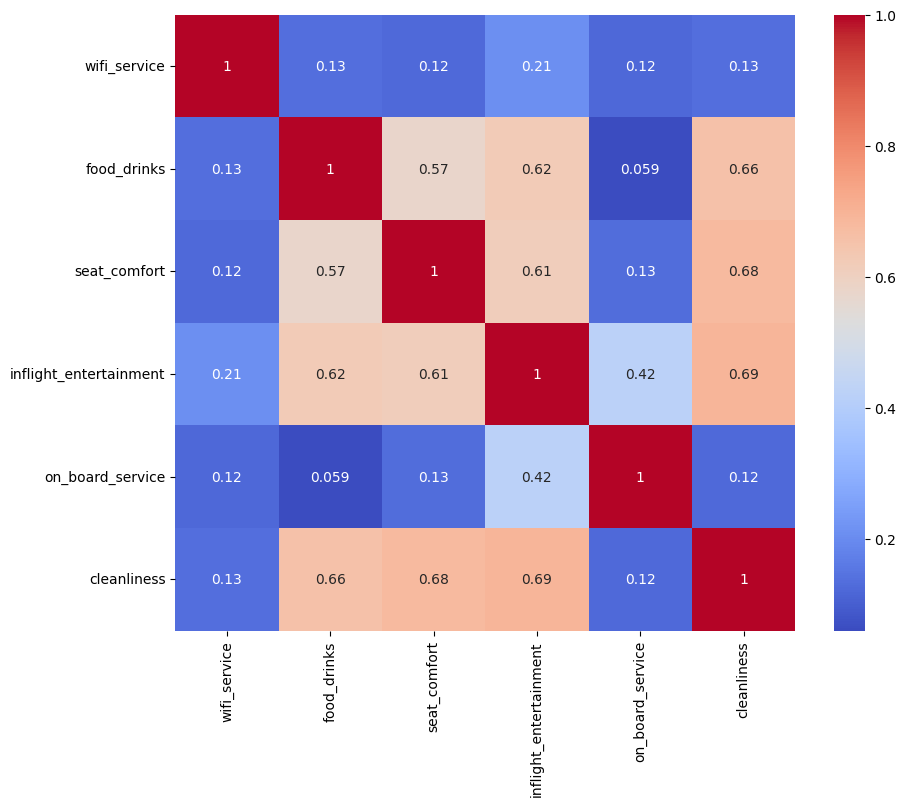

In [73]:
rating_colls =['wifi_service','food_drinks','seat_comfort','inflight_entertainment','on_board_service','cleanliness']
plt.figure(figsize=(10,8))
sns.heatmap(df[rating_colls].corr(),annot= True,cmap='coolwarm')
plt.show()

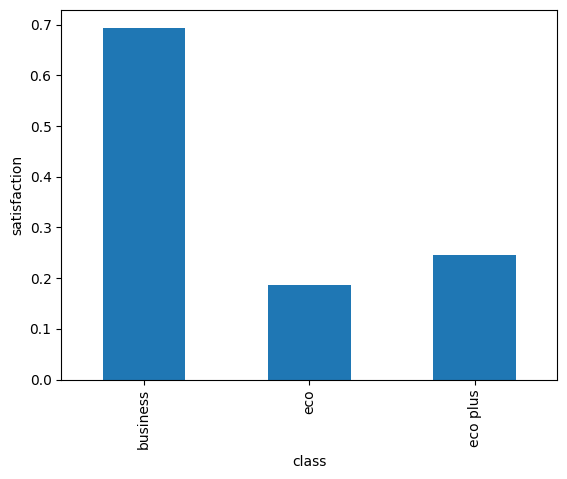

In [74]:
df.groupby('class')['sat_num'].mean().plot(kind='bar')
plt.ylabel('satisfaction')
plt.show()

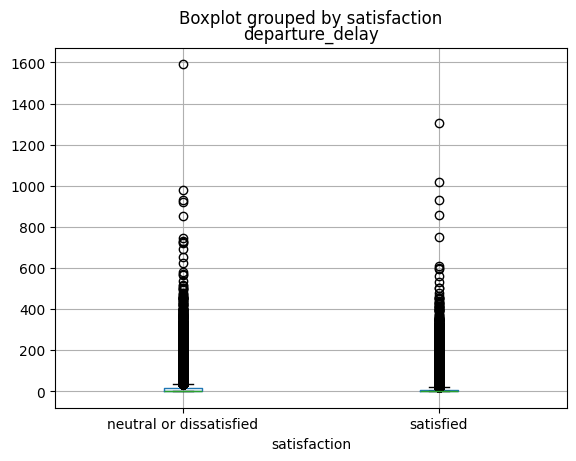

In [75]:
df.boxplot(column='departure_delay',by='satisfaction')
plt.show()

In [76]:
q1 = df['flight_distance'].quantile(0.25)
q3 = df['flight_distance'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5 * iqr
df_no_outliers = df[(df['flight_distance'] > lower) & (df['flight_distance'] <= upper)]
df_no_outliers

,id,gender,customer_type,age,travelling_type,class,flight_distance,wifi_service,departure_arrival_time,ease_online_booking,...,checkin_service,inflight_service,cleanliness,departure_delay,arrival_delay,satisfaction,age_group,delay_group,service_score,sat_num
0,70172,male,loyal customer,13,personal travel,eco plus,460,3,4,3,...,4,5,5,25,18.0,neutral or dissatisfied,under 18,15-30,4.181818,False
1,5047,male,disloyal customer,25,business travel,business,235,3,2,3,...,1,4,1,1,6.0,neutral or dissatisfied,18-30,no delay,2.181818,False
2,110028,female,loyal customer,26,business travel,business,1142,2,2,2,...,4,4,5,0,0.0,satisfied,18-30,NaN,4.181818,True
3,24026,female,loyal customer,25,business travel,business,562,2,5,5,...,1,4,2,11,9.0,neutral or dissatisfied,18-30,no delay,2.454545,False
4,119299,male,loyal customer,61,business travel,business,214,3,3,3,...,3,3,3,0,0.0,satisfied,60+,NaN,3.636364,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,94171,female,disloyal customer,23,business travel,eco,192,2,1,2,...,2,3,2,3,0.0,neutral or dissatisfied,18-30,no delay,2.272727,False
103900,73097,male,loyal customer,49,business travel,business,2347,4,4,4,...,5,5,4,0,0.0,satisfied,46-60,NaN,4.454545,True
103901,68825,male,disloyal customer,30,business travel,business,1995,1,1,1,...,5,5,4,7,14.0,neutral or dissatisfied,18-30,no delay,3.454545,False
103902,54173,female,disloyal customer,22,business travel,eco,1000,1,1,1,...,5,4,1,0,0.0,neutral or dissatisfied,18-30,NaN,2.272727,False
